Created by Justin Cooke 02/11/2026

The purpose of this script is to investigate the influence of spatial area on the common mode, with implications for variance.

Comparison of variance between HYCOM in the region of 22N to 28N and 83W to 90W vs in the CPIES region of 25 to 27.5N and 86W to 89W revealed the CPIES Variance to be 2.5x less than that in the HYCOM, despite having higher EKE.

In [1]:
# Import modules

# Sci computing
import numpy as np
import scipy as sp
import seawater as sw
import scipy.sparse.linalg as sla
import scipy.io as spio
from scipy import stats
from contourpy import contour_generator
import pyfftw 

# Importing bathymetry (tiff)
import rasterio as geo

# Parallel comupting
from dask.distributed import Client, LocalCluster
from dask.diagnostics import ProgressBar

# For Data
import netCDF4 as nc
import xarray as xr

# Plotting stuff
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grdspc
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
import cmocean as cm

# Gen stuff
from datetime import date
today = date.today()
import glob


import warnings
warnings.filterwarnings('ignore')

/tmp/ipykernel_2551040/1009159744.py:6: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
# Low Pass Filter

from scipy.signal import butter, filtfilt

def lowpassfilt(data, filtT, sampT):
    """
    Low-pass filter a 1D data vector using a second-order Butterworth filter.
    Filtering is applied forward and backward to eliminate phase shift.

    Parameters
    ----------
    data : array_like
        Input data vector (1D array). Can be row or column oriented.
    filtT : float
        Filter period (same units as sampT).
    sampT : float
        Sampling period (same units as filtT).

    Returns
    -------
    out : ndarray
        Filtered data vector, same shape as input.
    """

    data = np.asarray(data)
    if data.ndim != 1:
        raise ValueError("Input must be a 1D vector, not an array.")

    # Check if input was a row vector (for shape preservation)
    was_row = data.ndim == 1 and data.shape[0] < data.shape[-1]

    # Remove linear trend between endpoints
    n = len(data)
    x = np.arange(1, n + 1)
    p = np.polyfit([1, n], [data[0], data[-1]], 1)
    lineartrend = np.polyval(p, x)
    detrended = data - lineartrend

    # Check for NaNs
    if np.isnan(detrended).any():
        raise ValueError("Data contains NaNs; remove them before filtering.")

    # Butterworth filter setup
    # Wn is the normalized cutoff frequency (Nyquist = 0.5 / sampT)
    Wn = (2.0 / filtT) * sampT
    if Wn >= 1:
        raise ValueError("Cutoff frequency too high; ensure filtT > 2 * sampT.")
    b, a = butter(2, Wn)

    # Zero-phase filtering
    filtered = filtfilt(b, a, detrended)

    # Add linear trend back
    out = filtered + lineartrend

    # Preserve input orientation
    if was_row:
        out = out.reshape(1, -1)
    else:
        out = out.reshape(-1)

    return out


# Band-pass filter

def butterfilt_bandpass(x, order, filtThi, filtTlo, sampT):
    """
    Band-pass Butterworth filter with zero-phase (forward–reverse) filtering.

    Parameters
    ----------
    x : array_like
        Input vector (row or column). Will be returned in the same orientation.
    order : int
        Order of the Butterworth filter.
    filtThi : float
        Longer period of the band (high cutoff).
    filtTlo : float
        Shorter period of the band (low cutoff).
    sampT : float
        Sampling period. Must have same units as filtThi/filtTlo.

    Returns
    -------
    out : ndarray
        Filtered data vector, same shape (row/column) as input.
    """

    x = np.asarray(x)

    # Ensure input is 1-D vector
    if x.ndim != 1 and not (x.ndim == 2 and 1 in x.shape):
        raise ValueError("Input must be a vector, not an array.")

    # Preserve original orientation
    transpose_back = False
    if x.ndim == 2:
        if x.shape[0] == 1:  # row vector
            x = x.flatten()
            transpose_back = True
        elif x.shape[1] == 1:  # column vector
            x = x.flatten()
        else:
            raise ValueError("Input must be a vector, not a matrix.")

    n = x.size

    # Trend removal (linear ramp)
    t = np.arange(1, n + 1)
    P = np.polyfit([1, n], [x[0], x[-1]], 1)
    linear_trend = np.polyval(P, t)
    x_detrended = x - linear_trend

    # Normalized band edges (MATLAB: Wnlo = (2/filtTlo)*sampT)
    Wnlo = (2.0 / filtTlo) * sampT  # upper normalized cutoff
    Wnhi = (2.0 / filtThi) * sampT  # lower normalized cutoff
    Wn = [Wnhi, Wnlo]

    # Create Butterworth filter
    b, a = butter(order, Wn, btype='bandpass')

    # NaN check
    if np.isnan(x_detrended).any():
        raise ValueError("NaNs present in input data. Remove them before filtering.")

    # Zero-phase filtering
    out = filtfilt(b, a, x_detrended)

    # MATLAB code *comments out* adding the trend back:
    # out = out + linear_trend
    # For direct equivalence, we keep it commented.
    
    # Reshape to original orientation
    if transpose_back:
        out = out[np.newaxis, :]

    return out


# Create a function that finds distance based on great circle distance -- output in km will convert to m

def dist_calc(lat1,lat2,lon1,lon2):

    RadEarth = 6371  # [km]

    # Convert points from degrees to radians
    phi_1 = np.deg2rad(lat1) 
    phi_2 = np.deg2rad(lat2)
    lam_1 = np.deg2rad(lon1)
    lam_2 = np.deg2rad(lon2)

    # take difference between lat and lon points
    delphi = phi_2 - phi_1
    dellam = lam_2 - lam_1

    # Calculate circle greatest distance
    thisDist = 2 * RadEarth * np.asin( np.sqrt(( 1 - np.cos((delphi)) +
                                    ((np.cos(phi_1)) * np.cos(phi_2) * 
                                    (1 - np.cos(dellam) ) )) / 2)) 
    
    # Convert from km to m
    thisDist = thisDist # * 1000
    
    return(thisDist)
# Function to calculate LC Length 

def xr_length_calc(ds):
    # This function calculates the LC length of altimeter data from an xarray

    # INPUTS:
    # ds: XArray data set that should have de-meaned adt and lat and lon dimensions

    # OUTPUTS:
    # length: The time-series of the LC length

    # Written by Justin Cooke, 2026

    RadEarth = 6371 # km

    dims = list(ds.dims)
    
    for n,dim in enumerate(dims):
        if (dim in 'MT') or (dim in 'time'):
            Nt = ds.shape[n]
            time_dim = ds.dims[n]
    
    for dim in dims:
        if dim in 'longitude':
            myX_coords = ds.coords[dim]
        elif dim in 'latitude':
            myY_coords = ds.coords[dim]

    length = np.zeros(Nt)

    for j in range(Nt):

        if time_dim == 'MT':
            z_field = ds.isel(MT=j)
        else:
            z_field = ds.isel(time=j)

        # Create a ContourGenerator instance once (x, y are 1D coordinate arrays)
        contour_gen = contour_generator(
            x=myX_coords, y=myY_coords, z=z_field,  # z will be passed per iteration
            line_type="Separate"          # ensures each contour is a separate array
        )

        # Generate contours for the j-th SSH slice at level 0.17
        contour_segments = contour_gen.lines(0.17)  # list of Nx2 arrays (x, y)

        curveLength = np.zeros(len(contour_segments))

        for k, seg in enumerate(contour_segments):
            myX = seg[:,0]
            myY = seg[:,1]

            YCheck = myY <= 22.5
            XCheck = myX >= -87

            if (-83 in myX) or (np.any(YCheck) and np.any(XCheck)):
                
                # Compute great-circle distance along the contour
                this_curve = 0.0
                for i in range(len(myX) - 1):
                    lam_1 = np.deg2rad(myX[i])
                    lam_2 = np.deg2rad(myX[i + 1])
                    phi_1 = np.deg2rad(myY[i])
                    phi_2 = np.deg2rad(myY[i + 1])

                    delphi = phi_2 - phi_1
                    dellam = lam_2 - lam_1

                    thisDist = 2 * RadEarth * np.asin( np.sqrt(( 1 - np.cos((delphi)) +
                                                    ((np.cos(phi_1)) * np.cos(phi_2) * 
                                                    (1 - np.cos(dellam) ) )) / 2)) 

                    this_curve += thisDist

                curveLength[k] = this_curve

        length[j] = np.sum(curveLength) if len(curveLength) > 0 else 0

    return(length)

In [3]:
# For plotting; have the bathymetry of the gulf

ds_gulf = geo.open('/home/justin_cooke_uri_edu/DeepCyclones/gulf.tiff')
#ds_gulf = geo.open('../gulf.tiff')
img = ds_gulf.read(1)

(gm,gn) = np.shape(img)
gulf_lon = np.linspace(-90,-82,gn)
gulf_lat = np.linspace(22,28,gm)

# To get the aspect ratio right
ymid = np.mean(gulf_lat)
ymid_rad = ymid*np.pi/180

# For plotting: labels

lon_xticks = np.array((-90,-89,-88,-87,-86,-85,-84,-83))
lon_xticklbls = ['$90^\circ$W','$89^\circ$W','$88^\circ$W','$87^\circ$W','$86^\circ$W','$85^\circ$W','$84^\circ$W','$83^\circ$W']

lat_yticks = np.array((22,23,24,25,26,27,28))
lat_yticklbls = ['$22^\circ$N','$23^\circ$N','$24^\circ$N','$25^\circ$N','$26^\circ$N','$27^\circ$N','$28^\circ$N']

In [4]:
# Load datasets

ds_eref      = xr.open_mfdataset('./hycom_data/CommonMode/hycom_etaref_*.nc',combine='nested',concat_dim='MT') # Eta ref
ds_eref_noCM = xr.open_mfdataset('./hycom_data/hycom_etaref_*.nc',combine='nested',concat_dim='MT') # Eta ref common mode removed
ds_ssh       = xr.load_dataset('./hycom_data/hycom_ssh_filtered.nc') # SSH
ds_u         = xr.load_dataset('./hycom_data/hycom_u.nc') # zonal velocity
ds_v         = xr.load_dataset('./hycom_data/hycom_v.nc') # Meridional velocity

In [5]:
# From the datasets, load the variables we care about

eref_wCM   = ds_eref['eta_ref_wCommonMode'] # Eta ref with the common mode
eref       = ds_eref_noCM['eta_ref'] # Eta ref common mode removed
ssh        = ds_ssh['ssh'] # SSH
ssh_demean = ssh - xr.DataArray.mean(ssh,dim=["Latitude","Longitude"],skipna=True) # SSH demeaned -- remove the daily spatial mean from SSH
u          = ds_u['u'] # U
u          = np.squeeze(u)
v          = ds_v['v'] # V
v          = np.squeeze(v)

lon = ds_eref['Longitude'] # Longitdue
lat = ds_eref['Latitude'] # Latitdue

Nt,Nlat,Nlon = eref_wCM.shape # Grab the dimensions of the eta ref array

In [6]:
# For our dataseat, calculate LC Characteristics
 
RadEarth = 6371  # [km]

LC = {
    'length': np.zeros(Nt),
    'west': np.zeros(Nt),
    'north': np.zeros(Nt)
}

for j in range(Nt):

    z_field = ssh_demean.isel(MT=j)

    # Create a ContourGenerator instance once (x, y are 1D coordinate arrays)
    contour_gen = contour_generator(
        x=lon, y=lat, z=z_field,  # z will be passed per iteration
        line_type="Separate"          # ensures each contour is a separate array
    )


    # Generate contours for the j-th SSH slice at level 0.17
    contour_segments = contour_gen.lines(0.17)  # list of Nx2 arrays (x, y)

    curveLength = np.zeros(len(contour_segments))
    curveWest = np.zeros(len(contour_segments))
    curveNorth = np.zeros(len(contour_segments))

    for k, seg in enumerate(contour_segments):
        myX = seg[:,0]
        myY = seg[:,1]

        YCheck = myY <= 22.1
        XCheck = myX >= -86.5

        if (-83 in myX) or (np.any(YCheck) and np.any(XCheck)):
            idx_candidates = np.where(myY >= 23)[0]
            idx_w = idx_candidates[-1] if len(idx_candidates) > 0 else None

            curveNorth[k] = np.max(myY)

            if idx_w is None or np.abs(myY[idx_w]) >= 89.9:
                curveWest[k] = 0
            else:
                curveWest[k] = myX[idx_w]

            # Compute great-circle distance along the contour
            this_curve = 0.0
            for i in range(len(myX) - 1):
                lam_1 = np.deg2rad(myX[i])
                lam_2 = np.deg2rad(myX[i + 1])
                phi_1 = np.deg2rad(myY[i])
                phi_2 = np.deg2rad(myY[i + 1])

                delphi = phi_2 - phi_1
                dellam = lam_2 - lam_1

                thisDist = 2 * RadEarth * np.asin( np.sqrt(( 1 - np.cos((delphi)) +
                                                  ((np.cos(phi_1)) * np.cos(phi_2) * 
                                                   (1 - np.cos(dellam) ) )) / 2)) 

                this_curve += thisDist

            curveLength[k] = this_curve

    LC['west'][j] = np.max(np.abs(curveWest)) if len(curveWest) > 0 else 0 # Westward extension of LC 
    LC['north'][j] = np.max(np.abs(curveNorth)) if len(curveNorth) > 0 else 0 # Northern extension of LC
    LC['length'][j] = np.sum(curveLength) if len(curveLength) > 0 else 0 # LC Length


In [53]:
# Calculate Mean Eddy Kinetic Energy
# EKE = (u'^2 + v'^2) / 2

# Create velocity anomalies

# convert to cm/s
u_cm = u 
v_cm = v 

u_prime = u_cm - xr.DataArray.mean(u_cm,dim='MT',skipna=True)
v_prime = v_cm - xr.DataArray.mean(v_cm,dim='MT',skipna=True)

EKE = ((u_prime ** 2) + (v_prime ** 2)) / 2
EKE_mean = xr.DataArray.mean(EKE,dim='MT',skipna=True)

EKE = EKE.assign_coords(Latitude=lat.values, Longitude=lon.values)

**Testing influence of Common Mode of Pressure Variance**

First, by seeing how spatial sampling could influence the common mode and in turn pressure/eta ref variance.
Second, seeing how temporal sampling could also influence pressure/eta ref variance.

In [8]:
# Create a smaller eref_wCM but in the cpies region only

# Create a bounding box
dsc_minlat = lat.values[81]
dsc_maxlat = lat.values[-15]

dsc_minlon = lon.values[25]
dsc_maxlon = lon.values[100]

print(f'Bounded by {dsc_minlat}N to {dsc_maxlat}N and {dsc_minlon}W to {dsc_maxlon}W')

# Select the values within the DSC bounding box and then avg them spatially
cpies_eref = eref_wCM.sel(Latitude=slice(dsc_minlat,dsc_maxlat),Longitude=slice(dsc_minlon,dsc_maxlon))
Nt_cpies,Nlat_cpies,Nlon_cpies = cpies_eref.shape

cpies_lon = lon.values[25:101]
cpies_lat = lat.values[81:-14]

ssh_demean = ssh_demean.assign_coords(Latitude=lat.values, Longitude=lon.values)

# Also do the same for the SSH
cpies_ssh_demean = ssh_demean.sel(Latitude=slice(dsc_minlat,dsc_maxlat),Longitude=slice(dsc_minlon,dsc_maxlon))

# And for EKE
cpies_eke = EKE.sel(Latitude=slice(dsc_minlat,dsc_maxlat),Longitude=slice(dsc_minlon,dsc_maxlon))

# Also want the mean EKE over that region
cpies_eke_mean = xr.DataArray.mean(cpies_eke,dim=["Latitude","Longitude"],skipna=True)

Bounded by 25.006114959716797N to 27.51681137084961N and -89.0W to -86.0W


4420 5150


Text(0.5, 1.0, 'Common Mode from Randomly Sampled 2-year Interval')

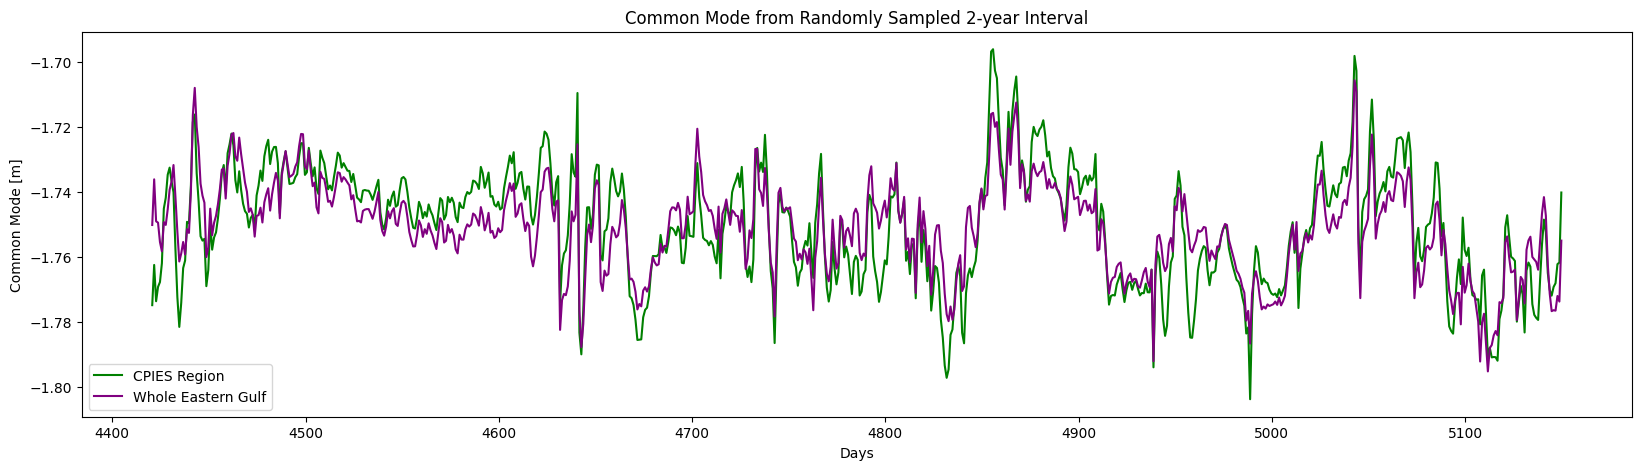

In [9]:
# Create and find random two year intervals
Nt_lim = Nt - 2*365 - 1

import random
my_start_idx = random.randint(0,Nt_lim)
my_end_idx = my_start_idx + 2*365

print(my_start_idx,my_end_idx)

# Two year intervals taken from whole field and cpies region limited field (both have common mode still)
eref_2yrs = eref_wCM[my_start_idx:my_end_idx,:,:]
cpies_2yrs = cpies_eref[my_start_idx:my_end_idx,:,:]

# Create time axis
time_axis = np.linspace(0,Nt,Nt)
time_2yr_axis = time_axis[my_start_idx:my_end_idx]

# Remove common mode from randomly sampled two year interval for both Eastern Gulf and CPIES region 
eref_noCM = eref_2yrs - xr.DataArray.mean(eref_2yrs,dim=["Latitude","Longitude"],skipna=True)
cpies_eref_noCM = cpies_2yrs - xr.DataArray.mean(cpies_2yrs,dim=["Latitude","Longitude"],skipna=True)

# Remove common mode from full 18 year time-series for both Eastern Gulf and CPIES region 
full_eref_noCM = eref_wCM - xr.DataArray.mean(eref_wCM,dim=["Latitude","Longitude"],skipna=True)
full_cpies_eref_noCM = cpies_eref - xr.DataArray.mean(cpies_eref,dim=["Latitude","Longitude"],skipna=True)

# Common mode from full 18 year time-series for both Eastern Gulf and CPIES region 
full_big_CM = xr.DataArray.mean(eref_wCM,dim=["Latitude","Longitude"],skipna=True)
full_small_CM = xr.DataArray.mean(cpies_eref,dim=["Latitude","Longitude"],skipna=True)

# Common mode from randomly sampled two year interval for both Eastern Gulf and CPIES region 
big_CM = xr.DataArray.mean(eref_2yrs,dim=["Latitude","Longitude"],skipna=True)
small_CM = xr.DataArray.mean(cpies_2yrs,dim=["Latitude","Longitude"],skipna=True)

# Look at what the random time-series looks like
fig = plt.subplots(figsize=(20,5))

plt.plot(time_2yr_axis,small_CM,color='green',linestyle='-',label='CPIES Region')
plt.plot(time_2yr_axis,big_CM,color='purple',linestyle='-',label='Whole Eastern Gulf')
plt.xlabel('Days')
plt.ylabel('Common Mode [m]')
plt.legend(loc='lower left')
plt.title('Common Mode from Randomly Sampled 2-year Interval')

Text(0.5, 1.0, '150-60 Days')

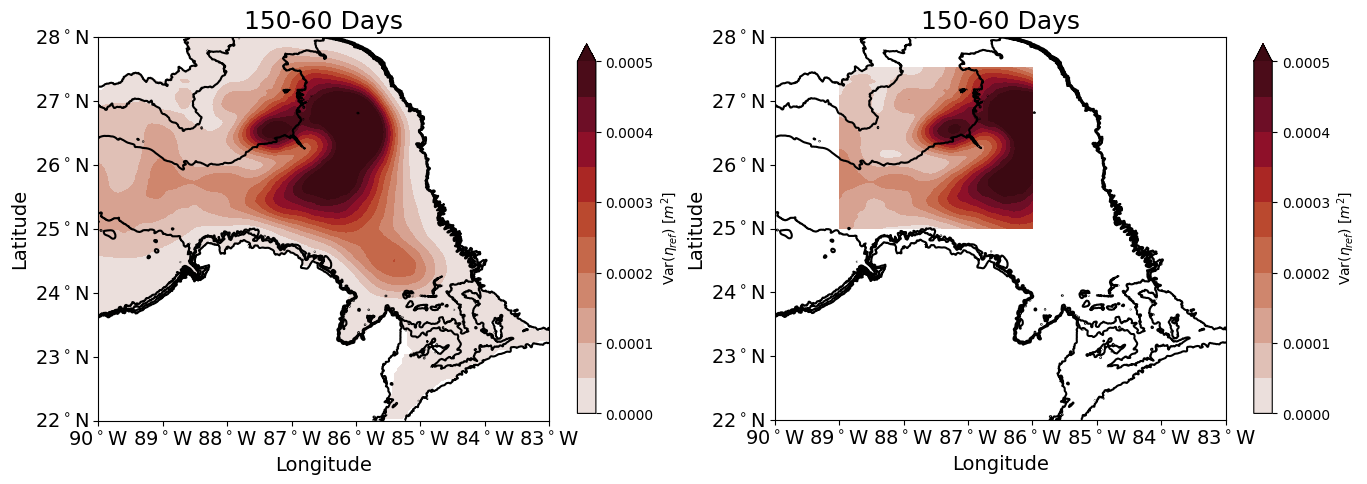

In [10]:
# We will now filter the eta ref datasets using low-pass and band-pass filters to compare spatial and temporal sampling

# Create the D Matrix

# Get eta ref values
eref_noCM_vals = eref_noCM.values
cpies_eref_noCM_vals = cpies_eref_noCM.values

Nt_now = eref_noCM_vals.shape[0]

# Create a mask containing all the points that are not NaNs
mask = ~np.isnan(eref_noCM_vals[0,:,:])
idx = np.where(mask)
mask_2 = ~np.isnan(cpies_eref_noCM_vals[0,:,:])
idx_2 = np.where(mask_2)

# Create D
D = eref_noCM_vals[:,idx[0],idx[1]]
D = np.moveaxis(D,0,1)
D_2 = cpies_eref_noCM_vals[:,idx_2[0],idx_2[1]]
D_2 = np.moveaxis(D_2,0,1)

bp_D = np.empty_like(D)
bp_D_2 = np.empty_like(D_2)

filtThi = 150.0
filtTlo = 60.0

fc = 10.0
sc = 1.0

for i in range(D.shape[0]):
    bp_D[i,:] = butterfilt_bandpass(D[i,:],2,filtThi,filtTlo,sc)
for i in range(D_2.shape[0]):
    bp_D_2[i,:] = butterfilt_bandpass(D_2[i,:],2,filtThi,filtTlo,sc)

eref_noCM_vals_bp = np.full((Nt_now,Nlat,Nlon),np.nan)
cpies_eref_noCM_vals_bp = np.full((Nt_now,Nlat_cpies,Nlon_cpies),np.nan)

for t in range(Nt_now):
    cpies_eref_noCM_vals_bp[t,idx_2[0],idx_2[1]] = bp_D_2[:,t]
    eref_noCM_vals_bp[t,idx[0],idx[1]] = bp_D[:,t]

cpies_eref_noCM_bp = xr.DataArray(
    cpies_eref_noCM_vals_bp,
    coords=cpies_eref_noCM.coords,
    dims=cpies_eref_noCM.dims,
    name='cpies_eref_noCM_bp'
)

eref_bp = xr.DataArray(
    eref_noCM_vals_bp,
    coords=eref_noCM.coords,
    dims=eref_noCM.dims,
    name='eref_noCM_bp'
)
# Plot variance of everything

fig = plt.subplots(1,2,figsize=(16,8))

ax = plt.subplot(1,2,1)
#cb = ax.contourf(lon,lat,eref_18yr_mean,cmap=cm.cm.balance,levels=np.linspace(-0.04,0.04,11),extend='both')
cb = ax.contourf(lon,lat,np.nanvar(eref_noCM_vals_bp,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.0005,11),extend='max')
plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')#,location='bottom')
#plt.colorbar(cb,shrink=0.6,label='$\eta_{ref}$ [$m$]')#,location='bottom')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
#ax.set_title('18-year Variance of $\eta_{ref}$',fontsize=18)
ax.set_title(f'{int(filtThi)}-{int(filtTlo)} Days',fontsize=18)

ax = plt.subplot(1,2,2)
#cb = ax.contourf(lon,lat,eref_18yr_mean,cmap=cm.cm.balance,levels=np.linspace(-0.04,0.04,11),extend='both')
cb = ax.contourf(cpies_lon,cpies_lat,np.nanvar(cpies_eref_noCM_vals_bp,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.0005,11),extend='max')
plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')#,location='bottom')
#plt.colorbar(cb,shrink=0.6,label='$\eta_{ref}$ [$m$]')#,location='bottom')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
#ax.set_title('18-year Variance of $\eta_{ref}$',fontsize=18)
ax.set_title(f'{int(filtThi)}-{int(filtTlo)} Days',fontsize=18)



#fig.savefig(f'./Figures/BP_{int(filtThi)}to{int(filtTlo)}_var_ampcolor_{today}.svg',format='svg')
#fig.savefig(f'./Figures/LP_{fc}_18yr_var_ampcolor_{today}.svg',format='svg')

**Another test for temporal sampling** 

Calculate variance in two year intervals and find the PDF, compare the variance against UGOS and DynLoop

In [11]:
# Now we want to calculate variance in two year intervals for the cpies region to create a pdf

# Want to get variance over 2 yeras 
two_yr_int = 365*2

# Allocate array
cpies_twoYr_meanvar = np.empty(17)
cpies_twoYr_var = np.empty((17,full_cpies_eref_noCM.values.shape[1],full_cpies_eref_noCM.values.shape[2]))
LCL_twoYr_mean = np.empty(17)
ssh_twoYr_meanvar = np.empty(17)
eke_twoYr_mean = np.empty(17)

# Calculate mean variance in two year intervals over cpies region
for n in range(17):
    my_start = n*365 # Interval start time
    my_end = my_start + two_yr_int # Interval end time
    #print(f'Start: {my_start}\nEnd: {my_end}')

    # First calculate the variance over the interval
    my_interval = full_cpies_eref_noCM.values[my_start:my_end,:,:] # Grab the interval from the full 18-year time-series and over the CPIES region
    this_var = np.nanvar(my_interval,axis=0) # Calculate the Variance

    # Next calculate the area averaged mean variance
    this_mean_var = np.nanmean(this_var,axis=(0,1))
    cpies_twoYr_var[n,:,:] = this_var # Spatial variance for each 2-year interval
    cpies_twoYr_meanvar[n] = this_mean_var # Mean variance for each 2-year interval

    # Now we want the average LC Length for the 2-year intervals
    length_interval = LC['length'][my_start:my_end] # Get the interval from the LC length time-series
    mean_length = np.mean(length_interval) # Calculate the mean length
    LCL_twoYr_mean[n] = mean_length

    # Get the average EKE in the cpies region 
    eke_interval = cpies_eke_mean[my_start:my_end]
    eke_twoYr_mean[n] = np.mean(eke_interval)

    # Finally get the mean SSH Variance for each interval
    my_ssh_interval = cpies_ssh_demean.values[my_start:my_end,:,:] # Get SSH fields from the 2-year interval
    this_ssh_var = np.nanvar(my_ssh_interval,axis=0) # Calculate the variance 
    this_mean_ssh_var = np.nanmean(this_ssh_var,axis=(0,1)) # Calculate the mean SSH Variance 
    ssh_twoYr_meanvar[n] = this_mean_ssh_var
    
    


In [12]:
# Calculate linear fits for scatter plots

s1,i1,r1,p1,serr1 = stats.linregress(LCL_twoYr_mean,eke_twoYr_mean)
s2,i2,r2,p2,serr2 = stats.linregress(ssh_twoYr_meanvar,eke_twoYr_mean)
s3,i3,r3,p3,serr3 = stats.linregress(LCL_twoYr_mean,cpies_twoYr_meanvar)
s4,i4,r4,p4,serr4 = stats.linregress(ssh_twoYr_meanvar,cpies_twoYr_meanvar)

r_sq1 = r1**2
r_sq2 = r2**2
r_sq3 = r3**2
r_sq4 = r4**2

line1 = s1*LCL_twoYr_mean + i1
line2 = s2*ssh_twoYr_meanvar + i2
line3 = s3*LCL_twoYr_mean + i3
line4 = s4*ssh_twoYr_meanvar + i4


In [13]:
# Load the CPIES data


ds_oi_ugos = spio.loadmat('/home/justin_cooke_uri_edu/DeepCyclones/EF/ObsData/OImapBottomPrs_20d_70k_65k_15Vn.mat')
#ds_oi = spio.loadmat('./ObsData/OImapBottomPrs_20d_70k_65k_15Vn.mat')

oi_lat_ugos = ds_oi_ugos['OIprs']['lat'][0][0]
oi_lon_ugos = ds_oi_ugos['OIprs']['lon'][0][0]

# Let's grab that subset of data and then average to have 24 hour times 
oi_prs = ds_oi_ugos['OIprs']['prs'][0][0]

(nlat,nlon,nt) = oi_prs.shape

oi_prs_daily = np.zeros((nlat,nlon,nt))


countMe = 0
j = 0
while j < ((nt) - 1):
    firstHalf = oi_prs[:,:,j]
    secondHalf = oi_prs[:,:,j+1]

    avg_val = (firstHalf + secondHalf) / 2 
    oi_prs_daily[:,:,countMe] = avg_val
    
    countMe += 1
    
    j += 2

# output: [lat x lon x time]
oi_eref_daily_ugos = (oi_prs_daily*np.power(10,4))/(1040*9.81) # converts from pres to eta ref

oi_meanvar_ugos = np.mean(np.nanvar(oi_eref_daily_ugos,axis=2),axis=(0,1))

########## Do for Dynloop now

ds_oi_dyn = spio.loadmat('/home/justin_cooke_uri_edu/DeepCyclones/EF/ObsData/Dynloop_OImapBottomPrs_40d_70k_65k_15Vn.mat')
#ds_oi = spio.loadmat('./ObsData/OImapBottomPrs_20d_70k_65k_15Vn.mat')

oi_lat = ds_oi_dyn['OIprs']['lat'][0][0]
oi_lon = ds_oi_dyn['OIprs']['lon'][0][0]

# Let's grab that subset of data and then average to have 24 hour times 
oi_prs = ds_oi_dyn['OIprs']['prs'][0][0]

(nlat,nlon,nt) = oi_prs.shape

oi_prs_daily = np.zeros((nlat,nlon,nt))

countMe = 0
j = 0
while j < ((nt) - 1):
    firstHalf = oi_prs[:,:,j]
    secondHalf = oi_prs[:,:,j+1]

    avg_val = (firstHalf + secondHalf) / 2 
    oi_prs_daily[:,:,countMe] = avg_val
    
    countMe += 1
    
    j += 2

# output: [lat x lon x time]
oi_eref_daily_dyn = (oi_prs_daily*np.power(10,4))/(1040*9.81) # converts from pres to eta ref

oi_meanvar_dyn = np.mean(np.nanvar(oi_eref_daily_dyn,axis=2),axis=(0,1))

In [14]:
# Calculate EKE for UGOS and DynLoop

ugos_u = ds_oi_ugos['OIprs']['u'][0][0]
ugos_v = ds_oi_ugos['OIprs']['v'][0][0]

ugos_uprime = ugos_u - np.nanmean(ugos_u,axis=(2),keepdims=True)
ugos_vprime = ugos_v - np.nanmean(ugos_v,axis=(2),keepdims=True)

ugos_eke = ((ugos_uprime ** 2) + (ugos_vprime ** 2)) / 2
ugos_meanEKE = np.nanmean(ugos_eke,axis=2)
ugos_meanmeanEKE = np.nanmean(ugos_meanEKE,axis=(0,1))

dyn_u = ds_oi_dyn['OIprs']['u'][0][0]
dyn_v = ds_oi_dyn['OIprs']['v'][0][0]

dyn_uprime = dyn_u - np.nanmean(dyn_u,axis=(2),keepdims=True)
dyn_vprime = dyn_v - np.nanmean(dyn_v,axis=(2),keepdims=True)

dyn_eke = ((dyn_uprime ** 2) + (dyn_vprime ** 2)) / 2
dyn_meanEKE = np.mean(dyn_eke,axis=2)
dyn_meanmeanEKE = np.nanmean(dyn_meanEKE,axis=(0,1))

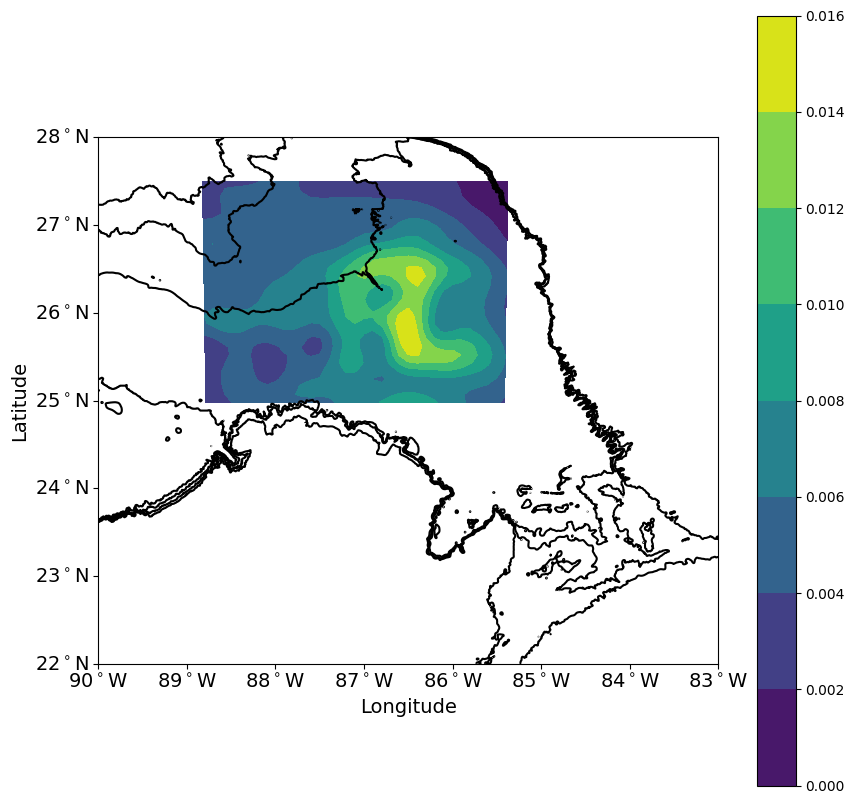

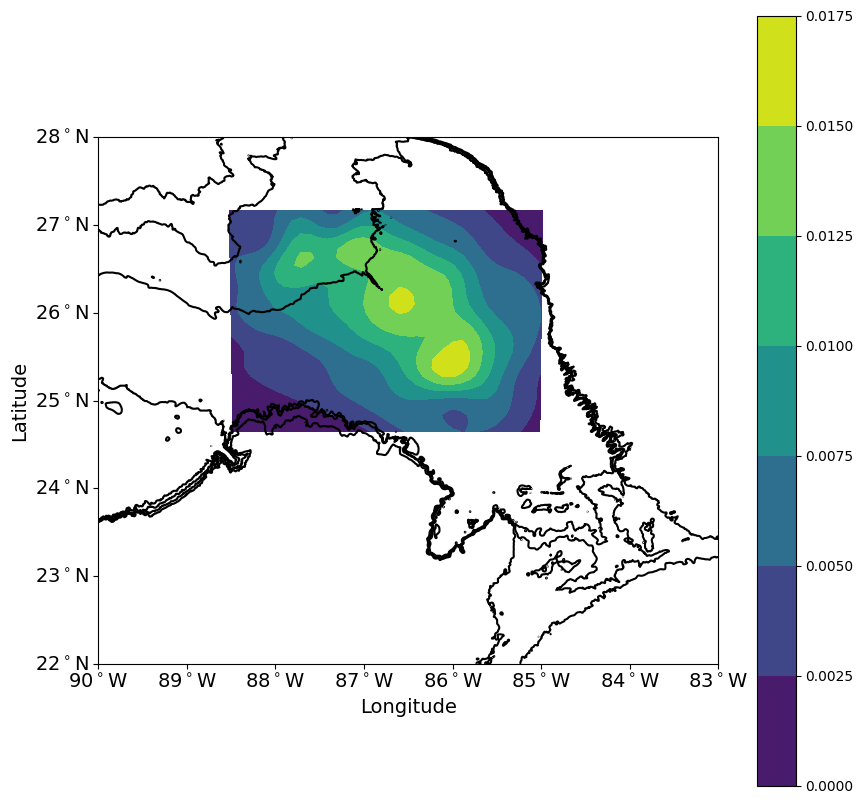

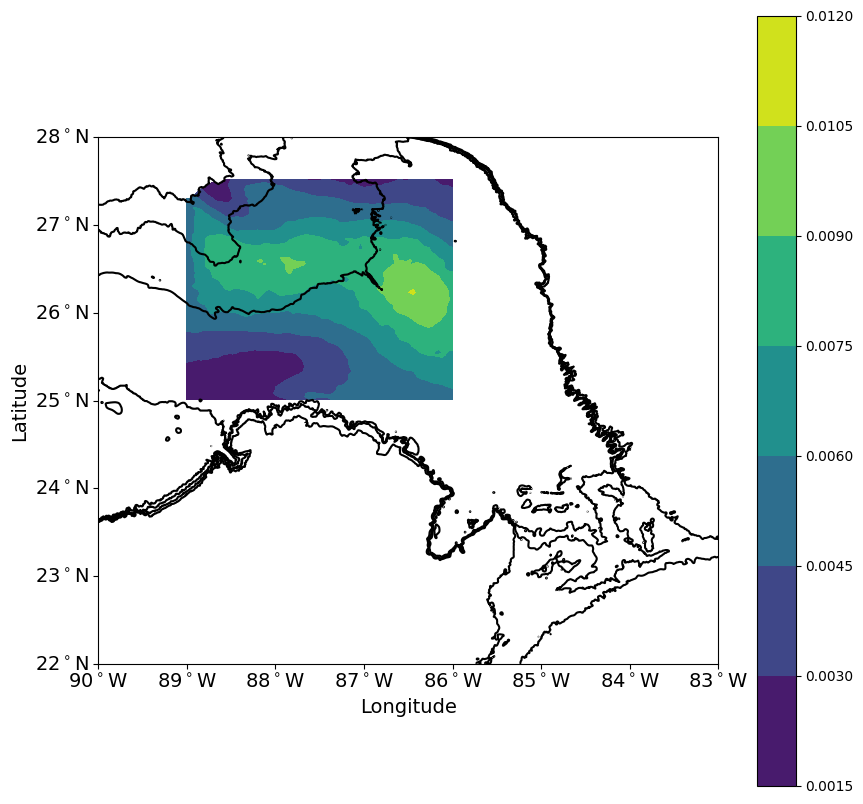

In [66]:
# Plot check for EKE in UGOS and DynLoop

fig,ax = plt.subplots(figsize=(10,10))

cb = ax.contourf(oi_lon_ugos,oi_lat_ugos,ugos_meanEKE)
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
plt.colorbar(cb)

fig,ax = plt.subplots(figsize=(10,10))

cb = ax.contourf(oi_lon,oi_lat,dyn_meanEKE)
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
plt.colorbar(cb)


cpies_eke_18yrmean = xr.DataArray.mean(cpies_eke,dim=["MT"],skipna=True)

fig,ax = plt.subplots(figsize=(10,10))

cb1 = ax.contourf(cpies_lon,cpies_lat,cpies_eke_18yrmean)
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
plt.colorbar(cb1)

In [16]:
# Load ssh data from the time of the UGOS 1 array and DynLoop array

# Load datasets
ds_ugos = spio.loadmat('/home/justin_cooke_uri_edu/DeepCyclones/ceofs/data/UGOS.mat')
ds_dynloop = spio.loadmat('/home/justin_cooke_uri_edu/DeepCyclones/ceofs/data/DynLoop.mat')

# First get the lons and lats for each dataset
ugos_adt_lon = np.squeeze(ds_ugos['ssh']['lon'][0][0])
ugos_adt_lat = np.squeeze(ds_ugos['ssh']['lat'][0][0])
ugos_adt_mt  = np.squeeze(ds_ugos['ssh']['mt'][0][0])

dyn_adt_lon = np.squeeze(ds_dynloop['ssh']['lon'][0][0])
dyn_adt_lat = np.squeeze(ds_dynloop['ssh']['lat'][0][0])
dyn_adt_mt  = np.squeeze(ds_dynloop['ssh']['dnum'][0][0])

# Now get the altimeter data
ugos_adt = ds_ugos['ssh']['adt'][0][0]
dyn_adt = ds_dynloop['ssh']['adt'][0][0]

# Convert to xarrays for manipulation
ugos_adt_xr = xr.DataArray(
    ugos_adt,
    coords={'lat': ugos_adt_lat,'lon': ugos_adt_lon, 'MT': ugos_adt_mt },
    dims=['lat','lon','MT'],
    name='ugos_adt'
)

dyn_adt_xr = xr.DataArray(
    dyn_adt,
    coords={'lat': dyn_adt_lat,'lon': dyn_adt_lon, 'MT': dyn_adt_mt},
    dims=['lat','lon','MT'],
    name='dynloop_adt'
)

# Now demean

ugos_adt_demean = ugos_adt_xr - xr.DataArray.mean(ugos_adt_xr,dim=["lat","lon"],skipna=True)
dyn_adt_demean  = dyn_adt_xr  - xr.DataArray.mean(dyn_adt_xr,dim=["lat","lon"],skipna=True)

ugos_adt_demean_vals = ugos_adt_demean.values
dyn_adt_demean_vals  = dyn_adt_demean.values

In [17]:
# Subset to only the Eastern Gulf

ugos_idx83 = np.where(ugos_adt_lon > -83)[0][0]
ugos_idx22 = np.where(ugos_adt_lat > 22)[0][0]
ugos_idx28 = np.where(ugos_adt_lat > 28)[0][0]

ugos_min_lat, ugos_max_lat = ugos_adt_lat[ugos_idx22], ugos_adt_lat[ugos_idx28-1]
ugos_max_lon = ugos_adt_lon[ugos_idx83-1]

ugos_subset = ugos_adt_demean.sel(lat=slice(ugos_min_lat,ugos_max_lat),lon=slice(ugos_adt_lon[0],ugos_max_lon))

dyn_idx83 = np.where(dyn_adt_lon > -83)[0][0]
dyn_idx22 = np.where(dyn_adt_lat > 22)[0][0]
dyn_idx28 = np.where(dyn_adt_lat > 28)[0][0]

dyn_min_lat, dyn_max_lat = dyn_adt_lat[dyn_idx22], dyn_adt_lat[dyn_idx28-1]
dyn_max_lon = dyn_adt_lon[dyn_idx83-1]

dyn_subset = dyn_adt_demean.sel(lat=slice(dyn_min_lat,dyn_max_lat),lon=slice(dyn_adt_lon[0],dyn_max_lon))

# Need to create even smaller subsets for CPIES region

cpies_ugos_idx86 = np.where(ugos_adt_lon > -86)[0][0]
cpies_ugos_idx89 = np.where(ugos_adt_lon > -89)[0][0]
cpies_ugos_idx22 = np.where(ugos_adt_lat > 25)[0][0]
cpies_ugos_idx28 = np.where(ugos_adt_lat > 27.5)[0][0]

cpies_ugos_min_lat, cpies_ugos_max_lat = ugos_adt_lat[cpies_ugos_idx22], ugos_adt_lat[cpies_ugos_idx28-1]
cpies_ugos_min_lon, cpies_ugos_max_lon = ugos_adt_lon[cpies_ugos_idx89], ugos_adt_lon[cpies_ugos_idx86-1]

cpies_ugos_subset = ugos_adt_demean.sel(lat=slice(cpies_ugos_min_lat,cpies_ugos_max_lat),lon=slice(cpies_ugos_min_lon,cpies_ugos_max_lon))

cpies_dyn_idx86 = np.where(dyn_adt_lon > -86)[0][0]
cpies_dyn_idx89 = np.where(dyn_adt_lon > -89)[0][0]
cpies_dyn_idx22 = np.where(dyn_adt_lat > 25)[0][0]
cpies_dyn_idx28 = np.where(dyn_adt_lat > 27.5)[0][0]

cpies_dyn_min_lat, cpies_dyn_max_lat = dyn_adt_lat[cpies_dyn_idx22], dyn_adt_lat[cpies_dyn_idx28-1]
cpies_dyn_min_lon, cpies_dyn_max_lon = dyn_adt_lon[cpies_dyn_idx89], dyn_adt_lon[cpies_dyn_idx86-1]

cpies_dyn_subset = dyn_adt_demean.sel(lat=slice(cpies_dyn_min_lat,cpies_dyn_max_lat),lon=slice(cpies_dyn_min_lon,cpies_dyn_max_lon))

In [18]:
ugos_length = xr_length_calc(ugos_subset)
ugos_length_mean = np.mean(ugos_length)
ugos_sshVar = np.nanvar(cpies_ugos_subset,axis=2)
ugos_sshVar_mean = np.nanmean(ugos_sshVar,axis=(0,1))
print(ugos_length_mean)

dyn_length  = xr_length_calc(dyn_subset)
dyn_length_mean  = np.mean(dyn_length)
dyn_sshVar = np.nanvar(cpies_dyn_subset,axis=2)
dyn_sshVar_mean = np.nanmean(dyn_sshVar,axis=(0,1))
print(dyn_length_mean)

LCL_obs = np.array([ugos_length_mean,dyn_length_mean])
var_obs = np.array([oi_meanvar_ugos,oi_meanvar_dyn])
sshVar_obs = np.array([ugos_sshVar_mean,dyn_sshVar_mean])
eke_obs = np.array([ugos_meanmeanEKE,dyn_meanmeanEKE])

977.7346686063124
993.0091647781792


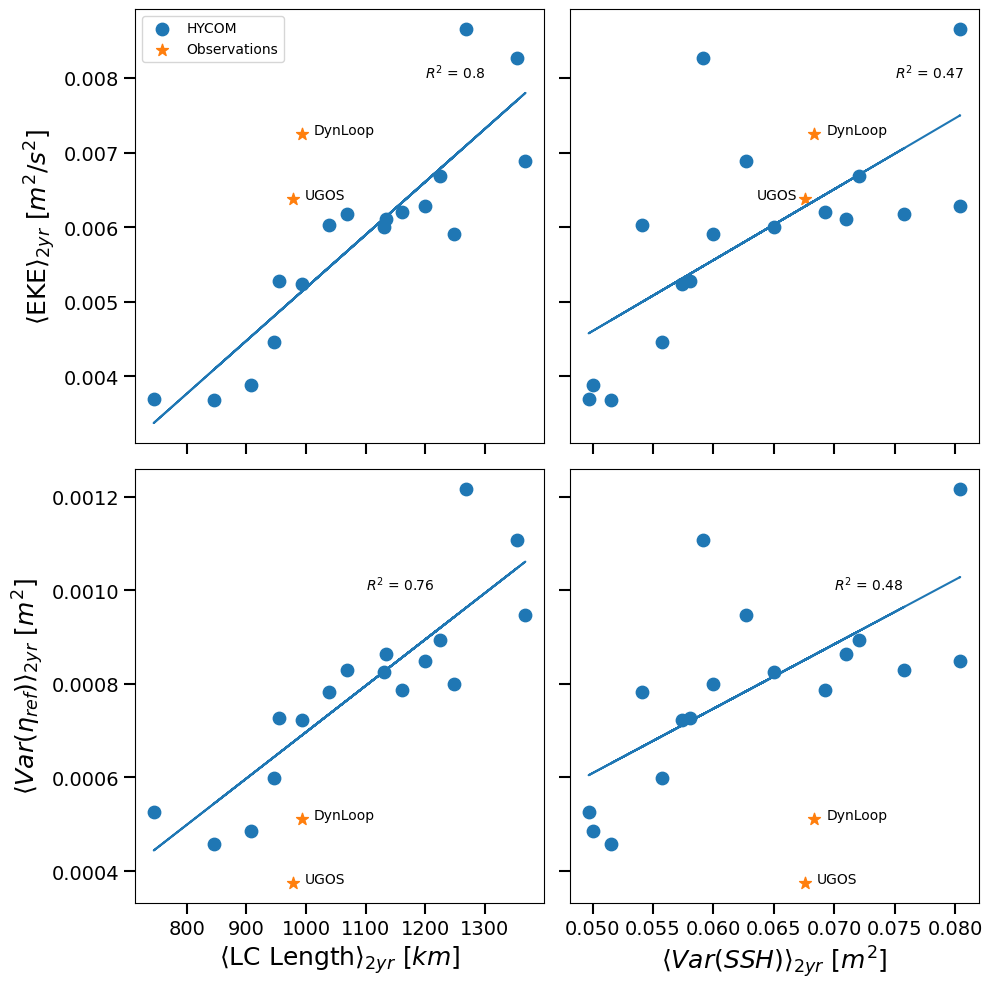

In [45]:
# Quad plot

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex='col', sharey='row')

# UPPER LEFT
ax1 = axes[0, 0]
ax1.scatter(LCL_twoYr_mean, eke_twoYr_mean,label='HYCOM',s=80)
ax1.scatter(LCL_obs,eke_obs,marker='*',label='Observations',s=80)
ax1.plot(LCL_twoYr_mean,line1)
ax1.text(1200,0.008,f'$R^2$ = {np.round(r_sq1,2)}')
ax1.text(LCL_obs[0]+20,eke_obs[0],'UGOS')
ax1.text(LCL_obs[1]+20,eke_obs[1],'DynLoop')

# UPPER RIGHT
ax2 = axes[0, 1]
ax2.scatter(ssh_twoYr_meanvar, eke_twoYr_mean,s=80)
ax2.scatter(sshVar_obs,eke_obs,marker='*',label='Observations',s=80)
ax2.plot(ssh_twoYr_meanvar,line2)
ax2.text(0.075,0.008,f'$R^2$ = {np.round(r_sq2,2)}')
ax2.text(sshVar_obs[0]-0.004,eke_obs[0],'UGOS')
ax2.text(sshVar_obs[1]+0.001,eke_obs[1],'DynLoop')

# BOTTOM LEFT
ax3 = axes[1, 0]
ax3.scatter(LCL_twoYr_mean, cpies_twoYr_meanvar,s=80)
ax3.scatter(LCL_obs,var_obs,marker='*',label='Observations',s=80)
ax3.plot(LCL_twoYr_mean,line3)
ax3.text(1100,0.001,f'$R^2$ = {np.round(r_sq3,2)}')
ax3.text(LCL_obs[0]+20,var_obs[0],'UGOS')
ax3.text(LCL_obs[1]+20,var_obs[1],'DynLoop')

# BOTTOM RIGHT
ax4 = axes[1, 1]
ax4.scatter(ssh_twoYr_meanvar, cpies_twoYr_meanvar,s=80)
ax4.scatter(sshVar_obs,var_obs,marker='*',label='Observations',s=80)
ax4.plot(ssh_twoYr_meanvar,line4)
ax4.text(0.07,0.001,f'$R^2$ = {np.round(r_sq4,2)}')
ax4.text(sshVar_obs[0]+0.001,var_obs[0],'UGOS')
ax4.text(sshVar_obs[1]+0.001,var_obs[1],'DynLoop')

# Cosmetics

# Left axes labels
ax1.set_ylabel(r'$\langle$EKE$\rangle_{2yr}$ [$m^2/s^2$]',fontsize=18)
ax3.set_ylabel(r'$\langle Var(\eta_{ref}) \rangle_{2yr}$ [$m^2$]',fontsize=18)
# Bottom axes labels
ax3.set_xlabel(r'$\langle$LC Length$\rangle_{2yr}$ [$km$]',fontsize=18)
ax4.set_xlabel(r'$\langle Var(SSH) \rangle_{2yr}$ [$m^2$]',fontsize=18)
# Legend
ax1.legend(loc='upper left')

for ax in axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=14, length=8, width=1.5)

plt.tight_layout()

In [47]:
cm_adt = xr.open_dataarray('./data/gulf_30yr_adt.nc')
cm_adt_lon = cm_adt['longitude'].values
cm_adt_lat = cm_adt['latitude'].values
cm_adt_demean = cm_adt - xr.DataArray.mean(cm_adt,dim=["latitude","longitude"],skipna=True)
cm_length = xr_length_calc(cm_adt_demean)

cpies_cm_idx86 = np.where(cm_adt_lon > -86)[0][0]
cpies_cm_idx89 = np.where(cm_adt_lon > -89)[0][0]
cpies_cm_idx22 = np.where(cm_adt_lat > 25)[0][0]
cpies_cm_idx28 = np.where(cm_adt_lat > 27.5)[0][0]

cpies_cm_min_lat, cpies_cm_max_lat = cm_adt_lat[cpies_cm_idx22], cm_adt_lat[cpies_cm_idx28-1]
cpies_cm_min_lon, cpies_cm_max_lon = cm_adt_lon[cpies_cm_idx89], cm_adt_lon[cpies_cm_idx86-1]

cpies_cm_subset = cm_adt_demean.sel(latitude=slice(cpies_cm_min_lat,cpies_cm_max_lat),longitude=slice(cpies_cm_min_lon,cpies_cm_max_lon))

cm_twoYr_mean = np.zeros(29)
cm_twoYr_meanvar = np.zeros(29)

# Calculate mean variance in two year intervals over cpies region
for n in range(29):
    my_start = n*365
    my_end = my_start + two_yr_int
    
    length_interval = cm_length[my_start:my_end]
    my_interval = cpies_cm_subset.values[my_start:my_end,:,:]
    this_var = np.nanvar(my_interval,axis=0)
    
    cm_twoYr_meanvar[n] = np.nanmean(this_var,axis=(0,1))
    
    mean_length = np.mean(length_interval)
    cm_twoYr_mean[n] = mean_length
    #print(f'Mean Variance: {this_mean_var}')

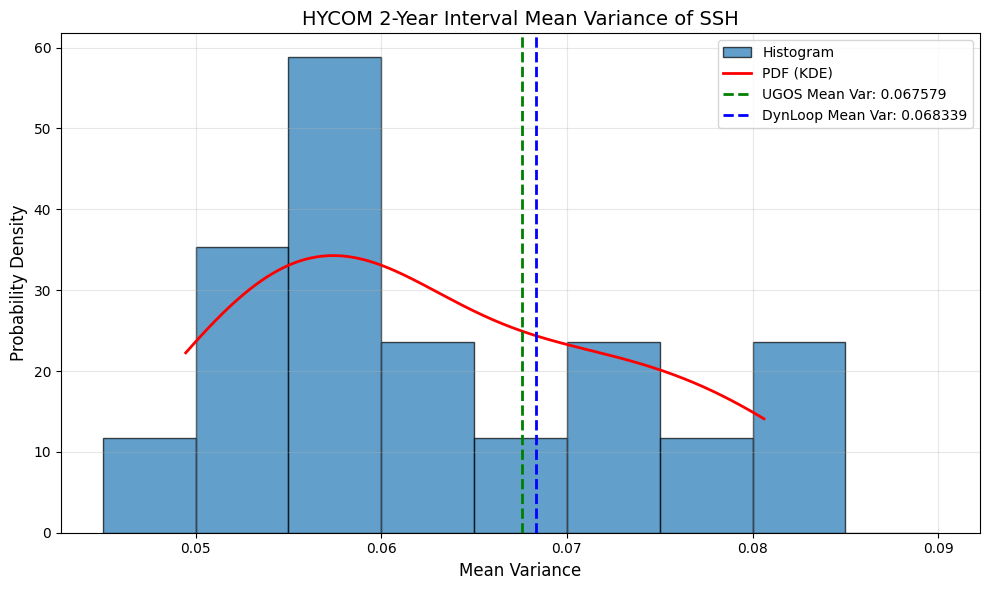

In [52]:
# Define bins with 0.00005 width
bin_width = 0.005
bin_min = np.floor(ssh_twoYr_meanvar.min() / bin_width) * bin_width
bin_max = np.ceil(ssh_twoYr_meanvar.max() / bin_width) * bin_width
bins = np.arange(bin_min, bin_max + bin_width, bin_width)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram (normalized to density)
ax.hist(ssh_twoYr_meanvar, bins=bins, density=True, alpha=0.7, 
        edgecolor='black', label='Histogram')

# Fit KDE for PDF estimation
kde = stats.gaussian_kde(ssh_twoYr_meanvar)
x_range = np.linspace(ssh_twoYr_meanvar.min() - 0.0002, 
                       ssh_twoYr_meanvar.max() + 0.0002, 500)
pdf = kde(x_range)

# Plot PDF
ax.plot(x_range, pdf, 'r-', linewidth=2, label='PDF (KDE)')

# Add vertical lines at the two points
ax.axvline(x=ugos_sshVar_mean, color='green', linestyle='--', linewidth=2, 
           label=f'UGOS Mean Var: {ugos_sshVar_mean:.6f}')
ax.axvline(x=dyn_sshVar_mean, color='blue', linestyle='--', linewidth=2, 
           label=f'DynLoop Mean Var: {dyn_sshVar_mean:.6f}')

# Labels and formatting
ax.set_xlabel('Mean Variance', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('HYCOM 2-Year Interval Mean Variance of SSH', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
fig,ax = plt.subplots(figsize=(10,10))

ax.scatter(cm_twoYr_mean,cm_twoYr_meanvar,label='CMEMS ADT 2-Year Interval',s=80)

ax.set_ylabel(r'$\langle$Var(SSH)$\rangle_{2yr}$ [$m^2$]')
ax.set_xlabel(r'$\langle$LC Length$\rangle_{2yr}$ [$km$]')
ax.legend(loc='upper right')


fig,ax = plt.subplots(figsize=(10,10))

ax.scatter(LCL_twoYr_mean,ssh_twoYr_meanvar,label='HYCOM 2-Year Interval',s=80)

ax.set_ylabel(r'$\langle$Var(SSH)$\rangle_{2yr}$ [$m^2$]')
ax.set_xlabel(r'$\langle$LC Length$\rangle_{2yr}$ [$km$]')
ax.legend(loc='upper right')

In [ ]:
bin_width = 100
bin_min = np.floor(LCL_twoYr_mean.min() / bin_width) * bin_width
bin_max = np.ceil(LCL_twoYr_mean.max() / bin_width) * bin_width
bins = np.arange(bin_min, bin_max + bin_width, bin_width)

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(20, 6))

ax1 = plt.subplot(1,2,1)
ax1.hist(LCL_twoYr_mean, bins=bins, density=True, alpha=0.7, 
        edgecolor='black')


# Fit KDE for PDF estimation
kde = stats.gaussian_kde(LCL_twoYr_mean)
x_range = np.linspace(LCL_twoYr_mean.min() - 0.0002, 
                       LCL_twoYr_mean.max() + 0.0002, 500)
pdf = kde(x_range)

# Plot PDF
ax1.plot(x_range, pdf, 'r-', linewidth=2, label='PDF (KDE)')

# Add vertical lines at the two points
ax1.axvline(x=ugos_length_mean, color='green', linestyle='--', linewidth=2, 
           label=f'UGOS Mean LC: {ugos_length_mean:.6f}')
ax1.axvline(x=dyn_length_mean, color='blue', linestyle='--', linewidth=2, 
           label=f'DynLoop Mean LC: {dyn_length_mean:.6f}')

# Labels and formatting
ax1.set_ylim(0,0.00325)
ax1.set_xlabel('Mean LC Length', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title('HYCOM 2-Year Interval Mean LC Length', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)


ax2 = plt.subplot(1,2,2)
plt.hist(cm_twoYr_mean, bins=bins, density=True, alpha=0.7, 
        edgecolor='black')

# Fit KDE for PDF estimation
kde = stats.gaussian_kde(cm_twoYr_mean)
x_range = np.linspace(cm_twoYr_mean.min() - 0.0002, 
                       cm_twoYr_mean.max() + 0.0002, 500)
pdf = kde(x_range)

# Plot PDF
ax2.plot(x_range, pdf, 'r-', linewidth=2, label='PDF (KDE)')

# Add vertical lines at the two points
ax2.axvline(x=ugos_length_mean, color='green', linestyle='--', linewidth=2, 
           label=f'UGOS Mean LC: {ugos_length_mean:.6f}')
ax2.axvline(x=dyn_length_mean, color='blue', linestyle='--', linewidth=2, 
           label=f'DynLoop Mean LC: {dyn_length_mean:.6f}')

# Labels and formatting
ax2.set_ylim(0,0.00325)
ax2.set_xlabel('Mean LC Length', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.set_title('CMEMS ADT 2-Year Interval Mean LC Length', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()



In [ ]:
# Plot copernicus LC Length

# Get dates of DynLoop and UGOS in 30 year Copernicus dataset
target_dates = [np.datetime64('2019-06-14'), np.datetime64('2021-05-19')]
idx = np.where(np.isin(cm_adt.coords['time'], target_dates))[0]

target_dates = [np.datetime64('2009-04-01'), np.datetime64('2011-11-01')]
idx1 = np.where(np.isin(cm_adt.coords['time'], target_dates))[0]

fig,ax = plt.subplots(figsize=(20,4))
plt.plot(cm_adt.coords['time'],cm_length,color='grey')
plt.vlines(cm_adt.coords['time'][idx],ymin=0,ymax=2000,color='green')
plt.vlines(cm_adt.coords['time'][idx1],ymin=0,ymax=2000,color='blue')

In [ ]:


# Define bins with 0.00005 width
bin_width = 0.00005
bin_min = np.floor(cpies_twoYr_meanvar.min() / bin_width) * bin_width
bin_max = np.ceil(cpies_twoYr_meanvar.max() / bin_width) * bin_width
bins = np.arange(bin_min, bin_max + bin_width, bin_width)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram (normalized to density)
ax.hist(cpies_twoYr_meanvar, bins=bins, density=True, alpha=0.7, 
        edgecolor='black', label='Histogram')

# Fit KDE for PDF estimation
kde = stats.gaussian_kde(cpies_twoYr_meanvar)
x_range = np.linspace(cpies_twoYr_meanvar.min() - 0.0002, 
                       cpies_twoYr_meanvar.max() + 0.0002, 500)
pdf = kde(x_range)

# Plot PDF
ax.plot(x_range, pdf, 'r-', linewidth=2, label='PDF (KDE)')

# Add vertical lines at the two points
ax.axvline(x=oi_meanvar_ugos, color='green', linestyle='--', linewidth=2, 
           label=f'UGOS Mean Var: {oi_meanvar_ugos:.6f}')
ax.axvline(x=oi_meanvar_dyn, color='blue', linestyle='--', linewidth=2, 
           label=f'DynLoop Mean Var: {oi_meanvar_dyn:.6f}')

# Labels and formatting
ax.set_xlabel('Mean Variance', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('HYCOM 2-Year Interval Mean Variance of $\eta_{ref}$', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
fig,ax = plt.subplots(figsize=(10,10))

#cb = ax.contourf(cpies_lon,cpies_lat,np.nanmean(cpies_twoYr_var,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.002,11),extend='max')
cb = ax.contourf(oi_lon_ugos,oi_lat_ugos,np.nanvar(oi_eref_daily_ugos,axis=2),cmap=cm.cm.amp,levels=np.linspace(0,0.002,11),extend='max')
#cb = ax.contourf(oi_lon,oi_lat,np.nanvar(oi_eref_daily_dyn,axis=2),cmap=cm.cm.amp,levels=np.linspace(0,0.002,11),extend='max')
plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')#,location='bottom')
#plt.colorbar(cb,shrink=0.6,label='$\eta_{ref}$ [$m$]')#,location='bottom')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
#plt.title('Composite of 2-Year Mean Variance of $\eta_{ref}$',fontsize=20)
plt.title('UGOS-1 Array Variance of $\eta_{ref}$',fontsize=20)
#plt.title('DynLoop Variance of $\eta_{ref}$',fontsize=20)

**Plot EKE**

In [ ]:
# Calculate Mean Eddy Kinetic Energy
# EKE = (u'^2 + v'^2) / 2

# Create velocity anomalies

# convert to cm/s
u_cm = u * 100
v_cm = v * 100

u_prime = u_cm - xr.DataArray.mean(u_cm,dim='MT',skipna=True)
v_prime = v_cm - xr.DataArray.mean(v_cm,dim='MT',skipna=True)

EKE = ((u_prime ** 2) + (v_prime ** 2)) / 2
EKE_mean = xr.DataArray.mean(EKE,dim='MT',skipna=True)

fig,ax = plt.subplots(figsize=(10,8))
cb = ax.contourf(lon,lat,EKE_mean,cmap='turbo',levels=np.linspace(0,150,16),extend='max')
plt.colorbar(cb,shrink=0.6,label='Mean EKE [$cm^2/s^2$]')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
ax.set_title('18-year Mean EKE at 2000m',fontsize=18)

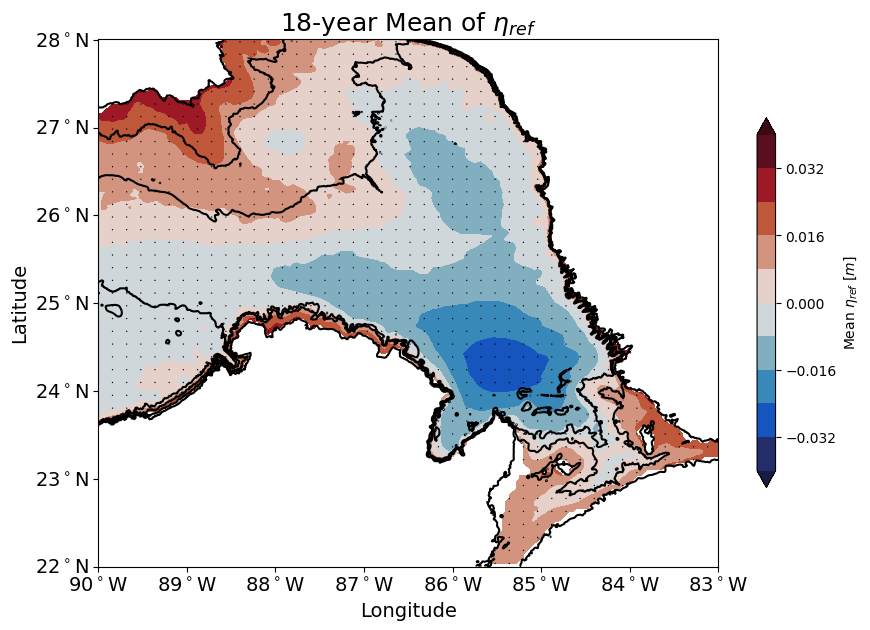

In [ ]:
# For plotting vectors

# 18 year mean of eta ref
eref_18yr_mean = np.nanmean(eref.values,axis=0)

# Get every third (or whatever) point 
u_mean = xr.DataArray.mean(u_cm,dim='MT',skipna=True)
v_mean = xr.DataArray.mean(v_cm,dim='MT',skipna=True)

# Downsample every third point
ds_val = 4
u_downsampled = u_mean.isel(Latitude=slice(0, None, ds_val), Longitude=slice(0, None, ds_val))
v_downsampled = v_mean.isel(Latitude=slice(0, None, ds_val), Longitude=slice(0, None, ds_val))
lon_downsampled = lon.isel(Longitude=slice(0, None, ds_val))
lat_downsampled = lat.isel(Latitude=slice(0, None, ds_val))

LON,LAT = np.meshgrid(lon_downsampled,lat_downsampled)

fig,ax = plt.subplots(figsize=(10,8))
#cb = ax.contourf(lon,lat,EKE_mean,cmap='turbo',levels=np.linspace(0,150,16),extend='max')
cb = ax.contourf(lon,lat,eref_18yr_mean,cmap=cm.cm.balance,levels=np.linspace(-0.04,0.04,11),extend='both')
plt.quiver(LON,LAT,u_downsampled,v_downsampled,scale=100)
#plt.colorbar(cb,shrink=0.6,label='Mean EKE [$cm^2/s^2$]')
plt.colorbar(cb,shrink=0.6,label='Mean $\eta_{ref}$ [$m$]')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
# ax.set_title('18-year Mean EKE at 2000m',fontsize=18)
ax.set_title('18-year Mean of $\eta_{ref}$',fontsize=18)

#fig.savefig(f'./Figures/EtaRef_Mean_withVelocityVectors_{today}.svg',format='svg')

**Last Check**

Need to see what correlation function of Eta_ref turns out to be.

Can load in the locations of the CPIES and grab the points closest 

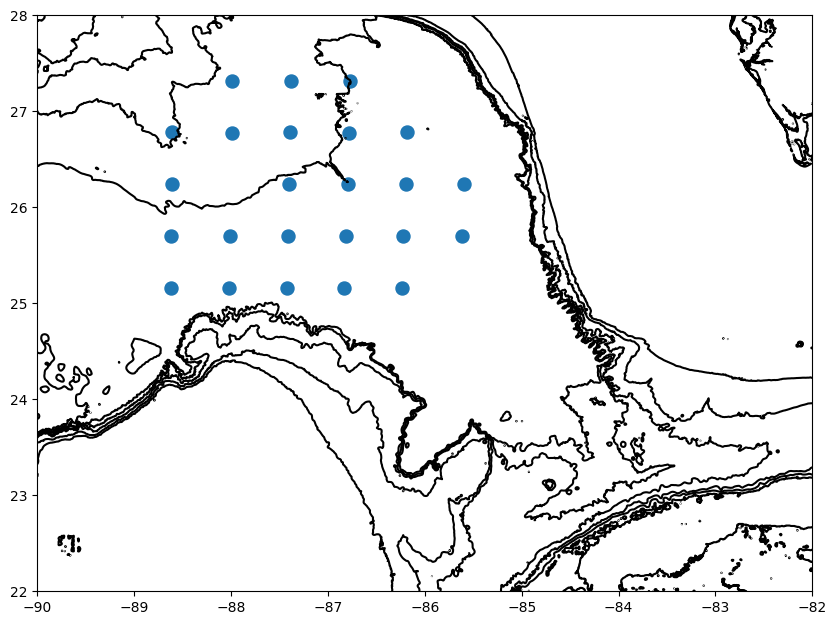

In [69]:
# Load CPIES locations 

ds_sites = spio.loadmat('/home/justin_cooke_uri_edu/DeepCyclones/EF/ObsData/sites.mat')

sites_lon = ds_sites['cpies']['lon'][0]
sites_lat = ds_sites['cpies']['lat'][0]

# sanity check plot
fig,ax = plt.subplots(figsize=(10,10))
plt.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-')
for i in range(len(sites_lon)):
    plt.scatter(sites_lon[i],sites_lat[i],s=88)
ax.set_aspect(np.cos(ymid))

In [70]:
hycom_sites = np.empty((len(sites_lon[0]),2))
hycom_idxes = np.empty((len(sites_lon[0]),2))
hycom_eref  = np.empty((len(sites_lon[0]),Nt))

for n in range(len(sites_lat[0])):
    site_lon = sites_lon[0][n]
    site_lat = sites_lat[0][n]

    idx_lon = np.where(lon.values >= site_lon)
    idx_lat = np.where(lat.values >= site_lat)

    hycom_sites[n,0] = lat.values[idx_lat[0][0]]
    hycom_sites[n,1] = lon.values[idx_lon[0][0]]

    hycom_idxes[n,0] = idx_lat[0][0]
    hycom_idxes[n,1] = idx_lon[0][0]

    hycom_eref[n,:] = full_eref_noCM[:,idx_lat[0][0],idx_lon[0][0]]


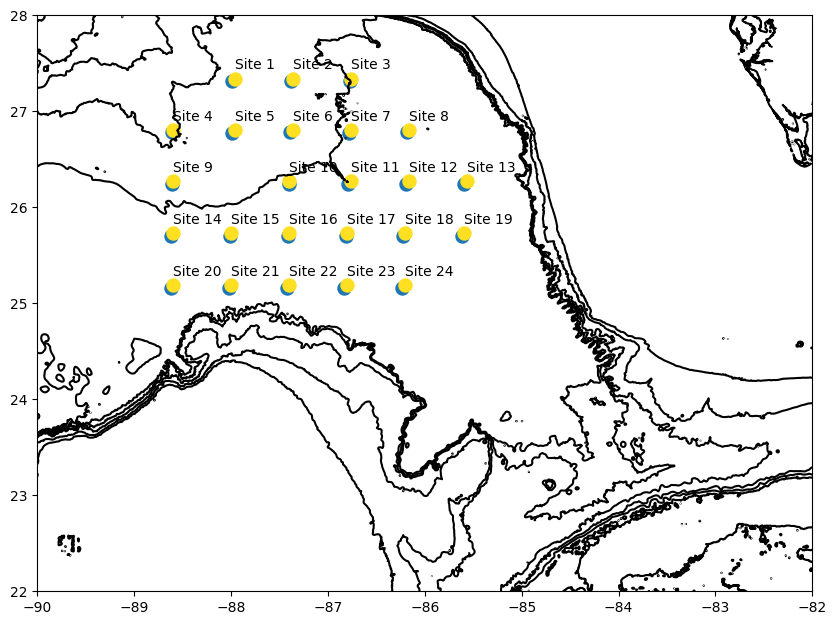

In [71]:
# sanity check plot
fig,ax = plt.subplots(figsize=(10,10))
plt.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-')
for i in range(len(sites_lon)):
    plt.scatter(sites_lon[i],sites_lat[i],s=88)
for n in range(24):
    plt.scatter(hycom_sites[n,1],hycom_sites[n,0],s=88,facecolors='xkcd:sun yellow')
    ax.text(hycom_sites[n,1],hycom_sites[n,0]+0.1,f'Site {n+1}')
ax.set_aspect(np.cos(ymid))

In [72]:
Nsites = hycom_sites.shape[0]
site_corr = np.empty((Nsites,Nsites-1))
site_dist = np.empty((Nsites,Nsites-1))

for n in range(Nsites):
    # get the first site that we will correlate all others against
    site_1 = (hycom_eref[n,:] - np.mean(hycom_eref[n,:]))
    lon_1 = hycom_sites[n,1]
    lat_1 = hycom_sites[n,0]
    counter = 0
        
    for m in range(Nsites):
        # make sure we are correlating against the same site
        if n != m:
            site_2 = (hycom_eref[m,:] - np.mean(hycom_eref[m,:]))
            lon_2 = hycom_sites[m,1]
            lat_2 = hycom_sites[m,0]
            
        else:
            continue

        site_dist[n,counter] = dist_calc(lat_1,lat_2,lon_1,lon_2)
        this_corr = np.corrcoef(site_1,site_2)
        site_corr[n,counter] = this_corr[0,1]
        counter += 1
        



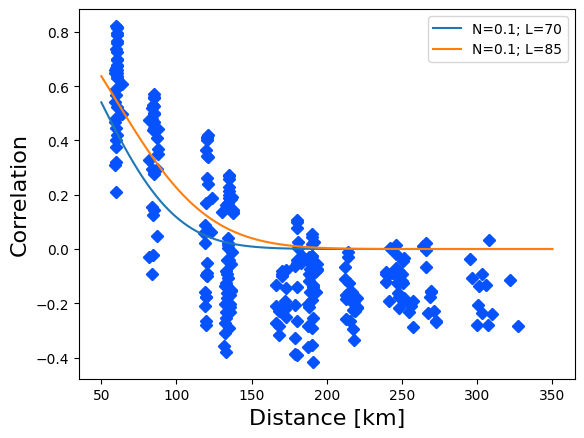

In [77]:
N = 0.1
r = np.linspace(50,350,100)
L1 = 70
L2 = 85
fit_check1 = (1-N) * np.exp(-1 * ((r/L1) ** 2))
fit_check2 = (1-N) * np.exp(-1 * ((r/L2) ** 2))

for n in range(Nsites):
    plt.scatter(site_dist[n,:],site_corr[n,:],facecolor='xkcd:electric blue',marker='D')
plt.plot(r,fit_check1,label=f'N=0.1; L={L1}')
plt.plot(r,fit_check2,label=f'N=0.1; L={L2}')
plt.ylabel('Correlation',fontsize=16)
plt.xlabel('Distance [km]',fontsize=16)
plt.legend(loc='upper right')